# Bearing Capacity of Shallow Foundations in Cohesionless soils: ####

## Data Loading & Preprocessing

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import math
from scipy.stats import zscore
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

In [3]:
# read csv file from google drive
df = pd.read_csv('merged_BC_dataset.csv')
df.head()

,B,D,LB,g,phi,BC
0,0.6,0.3,2.0,9.85,34.9,270.0
1,0.6,0.0,2.0,10.20,37.7,200.0
2,0.6,0.3,2.0,10.20,37.7,570.0
3,0.6,0.0,2.0,10.85,44.8,860.0
4,0.6,0.3,2.0,10.85,44.8,1760.0


In [4]:
# explore data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   B       183 non-null    float64
 1   D       183 non-null    float64
 2   LB      183 non-null    float64
 3   g       183 non-null    float64
 4   phi     183 non-null    float64
 5   BC      183 non-null    float64
dtypes: float64(6)
memory usage: 8.7 KB


In [5]:
# data statistics
df.describe()

,B,D,LB,g,phi,BC
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,0.503667,0.117224,2.438251,15.623005,39.181421,471.534809
std,0.553667,0.204319,2.056579,2.862648,3.427705,484.005435
min,0.030000,0.000000,1.000000,9.850000,31.950000,14.000000
25%,0.094000,0.000000,1.000000,13.900000,37.000000,145.550000
50%,0.460000,0.029000,1.000000,16.100000,39.500000,295.600000
75%,0.610000,0.094000,4.000000,17.100000,41.500000,606.125000
max,3.016000,0.890000,6.000000,20.800000,45.700000,2847.000000


In [6]:
# histogram
fig = make_subplots(rows=3, cols=3, subplot_titles=df.columns)

for i, col in enumerate(df.columns):
    row = i // 3 + 1; col_num = i % 3 + 1

    fig.add_trace( go.Histogram(x=df[col], nbinsx=20, name=col), row=row, col=col_num )

fig.update_layout( height=900, width=1200, title_text="Feature Distributions", showlegend=False)

fig.show()

In [7]:
# box plot
fig = make_subplots( rows=3, cols=3, subplot_titles=df.columns)

for i, col in enumerate(df.columns):
    row = i // 3 + 1; col_num = i % 3 + 1

    fig.add_trace(
        go.Box( y=df[col], name=col, boxpoints='all'), row=row, col=col_num )

fig.update_layout( height=900, width=1200, title_text="Features BoxPlot", showlegend=False)

fig.show()

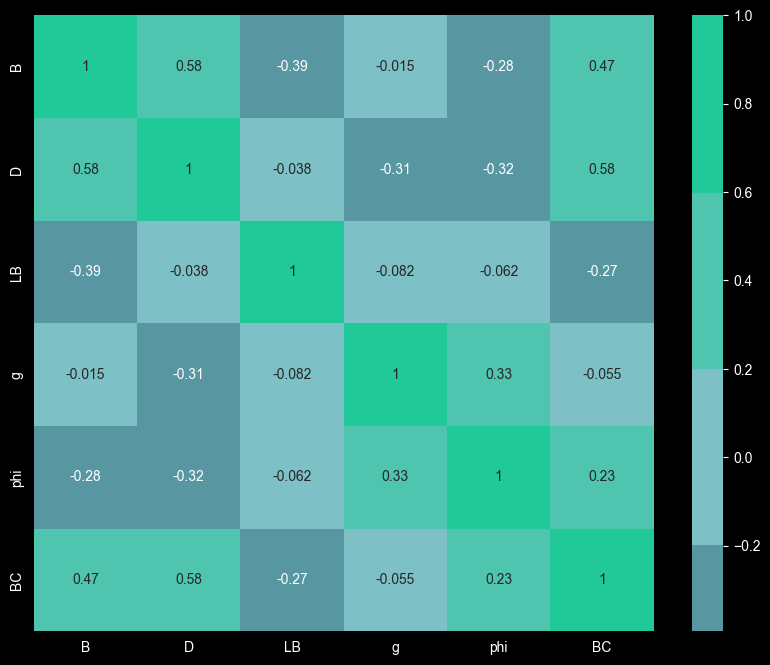

In [8]:
# heat map
cmap = LinearSegmentedColormap.from_list( 'custom', ['#326B7E', '#7DC0C6', '#20C997'], N=5)

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap=cmap, center=0)
plt.show()

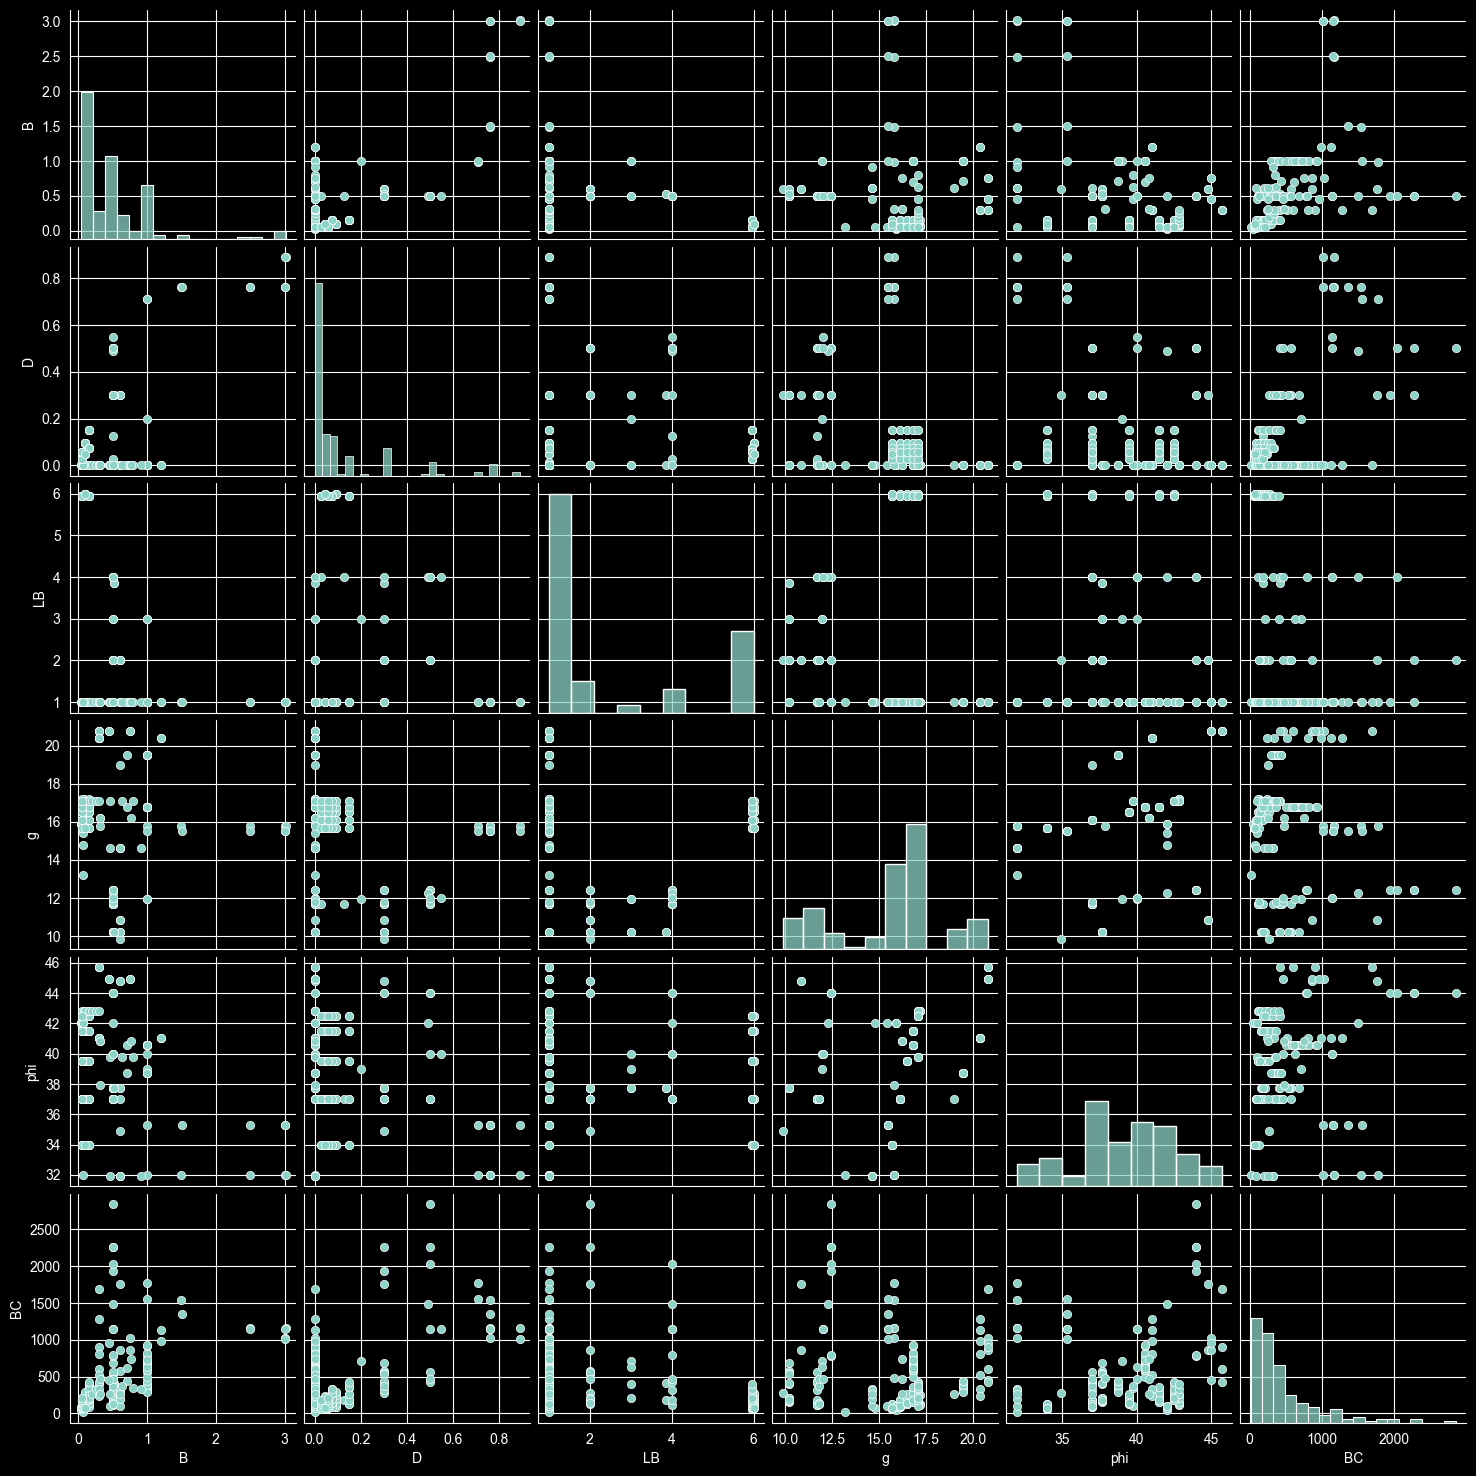

In [9]:
# pair plot
sns.pairplot(df)
plt.show()

from correlation heatmap and pair plot, it is clear that there are no strongly correlated features, showing features independency.

In [10]:
# data with BC>1300
df_BC_1300 = df[df['BC'] > 1300]
print('total count = ', len(df_BC_1300))
df_BC_1300

total count =  12


,B,D,LB,g,phi,BC
4,0.600,0.300,2.0,10.85,44.8,1760.00
29,0.500,0.300,1.0,12.41,44.0,1940.00
30,0.500,0.500,2.0,12.41,44.0,2266.00
31,0.500,0.500,2.0,12.41,44.0,2847.00
32,0.500,0.500,4.0,12.41,44.0,2033.00
33,0.500,0.490,4.0,12.27,42.0,1492.00
42,0.991,0.711,1.0,15.80,32.0,1773.70
45,1.492,0.762,1.0,15.80,32.0,1540.00
143,0.300,0.000,1.0,20.80,45.7,1688.89
164,1.000,0.710,1.0,15.50,35.3,1550.00


In [11]:
# data with B>1.2
df_B_12 = df[df['B'] > 1.2]
print('total count = ', len(df_B_12))
df_B_12

total count =  8


,B,D,LB,g,phi,BC
43,3.004,0.762,1.0,15.8,32.0,1019.40
44,2.489,0.762,1.0,15.8,32.0,1158.00
45,1.492,0.762,1.0,15.8,32.0,1540.00
46,3.016,0.889,1.0,15.8,32.0,1161.20
165,1.500,0.760,1.0,15.5,35.3,1355.56
166,2.500,0.760,1.0,15.5,35.3,1152.00
167,3.000,0.760,1.0,15.5,35.3,1144.44
168,3.000,0.890,1.0,15.5,35.3,1011.11


In [12]:
# data with D>0.2
df_D_02 = df[df['D'] > 0.2]
print('total count = ', len(df_D_02))
df_D_02

total count =  33


,B,D,LB,g,phi,BC
0,0.600,0.300,2.00,9.85,34.9,270.00
2,0.600,0.300,2.00,10.20,37.7,570.00
4,0.600,0.300,2.00,10.85,44.8,1760.00
11,0.500,0.300,1.00,10.20,37.7,681.00
12,0.500,0.300,2.00,10.20,37.7,542.00
13,0.500,0.300,2.00,10.20,37.7,530.00
14,0.500,0.300,3.00,10.20,37.7,402.00
15,0.520,0.300,3.85,10.20,37.7,413.00
22,0.500,0.300,1.00,11.70,37.0,406.00
23,0.500,0.300,1.00,11.70,37.0,446.00


In [13]:
# data with BC>1300 & B>1.2 & D>0.2
df_BC_B_D = df[(df['BC'] > 1300) & (df['B'] > 1.2) & (df['D'] > 0.2)]
print('total count = ', len(df_BC_B_D))
df_BC_B_D

total count =  2


,B,D,LB,g,phi,BC
45,1.492,0.762,1.0,15.8,32.0,1540.00
165,1.500,0.760,1.0,15.5,35.3,1355.56


In [14]:
# B & D Vs BC
fig = px.scatter( df, x='B', y='D', size='BC', color='BC', hover_data=df.columns, title='B vs D (Bubble size/color = BC)')

fig.update_layout( width=1000, height=700)
fig.show()

In [15]:
# pivot table
bins = [0,0.03, .09, 0.46, 0.61, 3.2]
labels = ['0-0.03', '0.03-0.09', '0.09-0.46', '0.46-0.61', '0.61-3.2']

df['B_range'] = pd.cut(df['B'], bins=bins, labels=labels)

pivot_df1 = pd.pivot_table( df, index='phi', columns='B_range', values='BC', aggfunc='mean')

pivot_df2 = pd.pivot_table( df, index='phi', columns='B_range', values='D', aggfunc='mean')

# count based on pivot
pivot_df3 = pd.pivot_table( df, index='phi', columns='B_range', values='BC', aggfunc='count')


# Combine the three tables
merged = pivot_df1.copy().astype(object)

for row in merged.index:
    for col in merged.columns:
        cnt = pivot_df3.loc[row, col]

        merged.loc[row, col] = (
            ""
            if pd.isna(cnt) or cnt == 0
            else f"D={pivot_df2.loc[row,col]:.2f},  "
                 f"BC={pivot_df1.loc[row,col]:.2f},  "
                 f"count={int(cnt)}"
        )

display(merged)

B_range,0-0.03,0.03-0.09,0.09-0.46,0.46-0.61,0.61-3.2
phi,,,,,
31.95,,,"D=0.00, BC=259.92, count=1","D=0.00, BC=204.24, count=3","D=0.00, BC=324.84, count=1"
32.00,,"D=0.00, BC=14.00, count=1",,,"D=0.78, BC=1330.46, count=5"
34.00,,"D=0.04, BC=64.70, count=4","D=0.09, BC=92.77, count=9",,
34.90,,,,"D=0.30, BC=270.00, count=1",
35.30,,,,,"D=0.78, BC=1242.62, count=5"
37.00,,"D=0.04, BC=90.72, count=4","D=0.09, BC=137.49, count=8","D=0.17, BC=262.06, count=17",
37.70,,,,"D=0.14, BC=342.69, count=13",
37.90,,,"D=0.00, BC=478.67, count=1",,
38.75,,,,,"D=0.00, BC=371.60, count=9"


from the merged table it seem that some values are not logic.

(phi=31.95, B=0.09-0.46)

(phi=37.9, B=0.09-0.46)

(phi=39.75, B=0.09-0.46)

(phi=40.8, B=0.09-0.46)

(phi=41, B=0.09-0.46)

In [16]:
# drop rows
rows_to_drop = ( (df['B_range'] == '0.09-0.46')   &   (df['phi'].isin([31.95, 37.9, 39.75, 40.8, 41]))  )

df = df[~rows_to_drop].copy()

print("Rows removed:", rows_to_drop.sum())
print("Remaining rows:", len(df))

Rows removed: 10
Remaining rows: 173


In [17]:
# pivot table for max values
bins = [0,0.03, .09, 0.46, 0.61, 3.2]
labels = ['0-0.03', '0.03-0.09', '0.09-0.46', '0.46-0.61', '0.61-3.2']

df['B_range'] = pd.cut(df['B'], bins=bins, labels=labels)

pivot_df4 = pd.pivot_table( df, index='phi', columns='B_range', values='BC', aggfunc='max' )

pivot_df5 = pd.pivot_table( df, index='phi', columns='B_range', values='D', aggfunc='max' )

# count
pivot_df6 = pd.pivot_table( df, index='phi', columns='B_range', values='BC', aggfunc='count' )

merged = pivot_df6.copy().astype(object)

for row in merged.index:
    for col in merged.columns:
        cnt = pivot_df6.loc[row, col]

        merged.loc[row, col] = (
            ""
            if pd.isna(cnt) or cnt == 0
            else f"D={pivot_df5.loc[row,col]:.2f},  "
                 f"BC={pivot_df4.loc[row,col]:.2f},  "
                 f"count={int(cnt)}"
        )

display(merged)

B_range,0-0.03,0.03-0.09,0.09-0.46,0.46-0.61,0.61-3.2
phi,,,,,
31.95,,,,"D=0.00, BC=322.49, count=3","D=0.00, BC=324.84, count=1"
32.00,,"D=0.00, BC=14.00, count=1",,,"D=0.89, BC=1773.70, count=5"
34.00,,"D=0.06, BC=70.91, count=4","D=0.15, BC=124.40, count=9",,
34.90,,,,"D=0.30, BC=270.00, count=1",
35.30,,,,,"D=0.89, BC=1550.00, count=5"
37.00,,"D=0.06, BC=98.93, count=4","D=0.15, BC=182.40, count=8","D=0.50, BC=565.00, count=17",
37.70,,,,"D=0.30, BC=681.00, count=13",
38.75,,,,,"D=0.00, BC=438.40, count=9"
39.00,,,,,"D=0.20, BC=710.00, count=1"


In [18]:
# rows with phi=44 & B_range 0.46-0.61
df_44_046_061 = df[
    (df['phi'] == 44) &
    (df['B_range'] == '0.46-0.61')
]

df_44_046_061


,B,D,LB,g,phi,BC,B_range
27,0.5,0.0,1.0,12.41,44.0,782.0,0.46-0.61
28,0.5,0.0,4.0,12.41,44.0,797.0,0.46-0.61
29,0.5,0.3,1.0,12.41,44.0,1940.0,0.46-0.61
30,0.5,0.5,2.0,12.41,44.0,2266.0,0.46-0.61
31,0.5,0.5,2.0,12.41,44.0,2847.0,0.46-0.61
32,0.5,0.5,4.0,12.41,44.0,2033.0,0.46-0.61
169,0.5,0.3,1.0,12.41,44.0,2266.0,0.46-0.61


from the above it doesn't make sense that rows like with indexes (30,31,32) have the same all features, but the result has a big variation from 2033 to 2847. So, we will check data for such cases and drop any non logical rows.

In [19]:
# conflicting rows
features = ['B', 'D', 'g', 'phi', 'LB']

conflicts = (
    df.groupby(features)['BC']
      .nunique()
      .reset_index(name='n_unique_BC') )

conflicts = conflicts[conflicts['n_unique_BC'] > 1]

display(conflicts)

,B,D,g,phi,LB,n_unique_BC
30,0.094,0.047,15.70,34.00,6.0,2
75,0.300,0.000,20.80,45.70,1.0,4
76,0.450,0.000,20.80,44.95,1.0,2
77,0.500,0.000,10.20,37.70,1.0,2
78,0.500,0.000,10.20,37.70,2.0,2
80,0.500,0.000,11.70,37.00,1.0,2
83,0.500,0.000,11.77,37.00,2.0,2
91,0.500,0.300,10.20,37.70,2.0,2
93,0.500,0.300,11.70,37.00,1.0,2
96,0.500,0.300,12.41,44.00,1.0,2


In [20]:
features = ['B', 'D', 'g', 'phi', 'LB']

conflict_rows = df.merge(
    conflicts[features],
    on=features,
    how='inner'
)

conflict_rows = conflict_rows.sort_values(features).drop(columns='B_range')

display(conflict_rows)

,B,D,LB,g,phi,BC
15,0.094,0.047,6.0,15.70,34.00,74.40
52,0.094,0.047,6.0,15.70,34.00,74.70
42,0.300,0.000,1.0,20.80,45.70,422.23
43,0.300,0.000,1.0,20.80,45.70,600.00
44,0.300,0.000,1.0,20.80,45.70,900.00
45,0.300,0.000,1.0,20.80,45.70,1688.89
40,0.450,0.000,1.0,20.80,44.95,953.09
41,0.450,0.000,1.0,20.80,44.95,454.32
0,0.500,0.000,1.0,10.20,37.70,154.00
1,0.500,0.000,1.0,10.20,37.70,165.00


In [21]:
features = ['B', 'D', 'g', 'phi', 'LB']

check = (
    df.groupby(features)['BC']
      .agg(['count', 'nunique', 'mean'])
      .query('nunique > 1')
)

display(check)

count  nunique         mean
B     D     g     phi   LB                              
0.094 0.047 15.70 34.00 6.0      2        2    74.550000
0.300 0.000 20.80 45.70 1.0      4        4   902.780000
0.450 0.000 20.80 44.95 1.0      2        2   703.705000
0.500 0.000 10.20 37.70 1.0      2        2   159.500000
                        2.0      2        2   199.000000
            11.70 37.00 1.0      2        2   121.500000
            11.77 37.00 2.0      2        2   128.500000
      0.300 10.20 37.70 2.0      2        2   536.000000
            11.70 37.00 1.0      2        2   426.000000
            12.41 44.00 1.0      2        2  2103.000000
      0.500 12.41 44.00 2.0      2        2  2556.500000
0.610 0.000 14.60 31.95 1.0      3        3   204.243333
0.750 0.000 20.80 44.95 1.0      2        2   938.670000
1.000 0.000 16.80 40.55 1.0     14       14   695.785714
            19.50 38.75 1.0      8        8   363.250000
1.200 0.000 20.40 41.00 1.0      2        2  1054.165000

In [22]:
# remove conflicting rows and replace with the mean for each row
features = ['B', 'D', 'g', 'phi', 'LB']

# Aggregate BC by identical inputs
df_clean = (
    df.groupby(features, as_index=False)
      .agg({'BC': 'mean'})
)

print(f"Original rows: {len(df)}")
print(f"Rows after merging duplicates: {len(df_clean)}")

Original rows: 173
Rows after merging duplicates: 136


In [23]:
# clean data
df_clean.describe()

,B,D,g,phi,LB,BC
count,136.000000,136.000000,136.000000,136.000000,136.000000,136.000000
mean,0.442699,0.147096,15.164118,38.952941,2.869118,425.266537
std,0.603520,0.221904,2.593627,3.478499,2.184440,471.963639
min,0.030000,0.000000,9.850000,31.950000,1.000000,14.000000
25%,0.094000,0.000000,12.410000,37.000000,1.000000,132.625000
50%,0.152000,0.058000,16.100000,39.500000,1.500000,221.400000
75%,0.500000,0.150000,16.800000,42.000000,5.950000,461.750000
max,3.016000,0.890000,20.800000,45.700000,6.000000,2556.500000


In [24]:
# clean data box plot
fig = make_subplots( rows=3, cols=3, subplot_titles=df_clean.columns )

for i, col in enumerate(df_clean.columns):
    row = i // 3 + 1
    col_num = i % 3 + 1

    fig.add_trace( go.Box( y=df_clean[col], name=col, boxpoints='all' ), row=row, col=col_num )

fig.update_layout( height=900, width=1200, title_text="Features BoxPlot", showlegend=False )

fig.show()

In [25]:
# percentage of tests pie chart
df_pie = df_clean.copy()
df_pie['Scale']=pd.cut(df_pie['B'],[0,.2,.5,1,np.inf],labels=['Small-scale','Medium-scale','Large-scale','Full-Scale'])

px.pie(df_pie,names='Scale',color='Scale', color_discrete_map={'Small-scale':'#326B7E','Medium-scale':'#20C997','Large-scale':'#7DC0C6', 'Full-scale':'#20C997'})\
.update_traces( textinfo='label+percent', textfont_size=20, marker_line_color='white', marker_line_width=2 )\
.update_layout( title='Test Scale Distribution', font_size=18 ).show()

## Machine Learning

### general

In [26]:
#!pip install optuna         # used as it learns from previous trials,
                             # and can reach goal with lower iterations than grid search that test all combinations of hyperparameters.
                             # also optuna provides pruning

In [27]:
#!pip install pysr

In [28]:
# import libraries
import optuna
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

from pysr import PySRRegressor

C:\Users\Ayman\ai-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [29]:
# preparing data
df_ml = df_clean.copy()

phi=np.radians(df_ml.phi)
df_ml['sin_phi']= np.sin(phi)
df_ml["tan_phi"]=np.tan(phi)
df_ml["Nq"]=np.exp(np.pi*np.tan(phi))*np.tan(np.pi/4+phi/2)**2
df_ml["Ngamma"]=2*(df_ml.Nq+1)*np.tan(phi)
df_ml["gammaB"]=df_ml.g*df_ml.B
df_ml["gammaD"]=df_ml.g*df_ml.D
df_ml["D_B"]=df_ml.D/df_ml.B

In [30]:
# evaluation matrix
def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    print(f"\n{name}\n{'='*40}"
          f"\nR²   : {r2_score(y_true,y_pred):.6f}"
          f"\nRMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):.6f}"
          f"\nMAE  : {mean_absolute_error(y_true,y_pred):.6f}"
          f"\nMAPE : {np.mean(np.abs((y_true-y_pred)/y_true))*100:.2f}%")

### XGBoost

In [31]:
#  XGBoost + Optuna
X_XGB, y = df_ml[['B','D','g','phi','LB']], df_ml['BC']
X_train_XGB, X_test_XGB, y_train, y_test = train_test_split(X_XGB, y, test_size=0.2, random_state=42, shuffle=True)
cv_XGB = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    XGB_model = XGBRegressor(
        n_estimators=trial.suggest_int('n_estimators',200,5000),
        max_depth=trial.suggest_int('max_depth',2,12),
        learning_rate=trial.suggest_float('learning_rate',1e-4,0.2,log=True),     # log means to test values on log scale rather than linear for thee value of learning rate
        min_child_weight=trial.suggest_int('min_child_weight',1,20),              # minimum sum of instance weights of a child node to split.
        gamma=trial.suggest_float('gamma',0,5),                                   # minimum loss reduction required to make a split
        subsample=trial.suggest_float('subsample',0.6,1.0),                       # specifies the fraction of training samples used to build each tree.
        colsample_bytree=trial.suggest_float('colsample_bytree',0.6,1.0),
        reg_alpha=trial.suggest_float('reg_alpha',0,10),                          # Regularization is a technique that penalizes model complexity during training so the model does not fit the training data too closely.
        reg_lambda=trial.suggest_float('reg_lambda',0,20),
        objective='reg:squarederror', tree_method='hist', random_state=42, n_jobs=-1    # MSE, feature values are grouped into bins, -1 → use all available CPU cores
    )
    return cross_val_score(XGB_model, X_train_XGB, y_train, cv=cv_XGB, scoring='r2', n_jobs=-1).mean()  # n_jobs specifies how many CPU cores (processor cores) to use for parallel computation.

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f"\nBest CV R² = {study.best_value:.6f}\n\nBest Parameters:\n{study.best_params}")

params = {**study.best_params, 'objective':'reg:squarederror', 'tree_method':'hist', 'random_state':42, 'n_jobs':-1}
XGB_model_best = XGBRegressor(**params).fit(X_train_XGB, y_train)

evaluate(y_train, XGB_model_best.predict(X_train_XGB), "TRAIN")
evaluate(y_test, XGB_model_best.predict(X_test_XGB), "TEST")

[I 2026-09-14 15:34:23,502] A new study created in memory with name: no-name-230f848f-922a-4bba-b902-91b8db203cc8
Best trial: 0. Best value: 0.832688:   0%|          | 1/300 [00:07<34:55,  7.01s/it]

[I 2026-09-14 15:34:30,509] Trial 0 finished with value: 0.8326884551501588 and parameters: {'n_estimators': 1998, 'max_depth': 12, 'learning_rate': 0.026081583694317685, 'min_child_weight': 12, 'gamma': 0.7800932022121826, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 8.661761457749352, 'reg_lambda': 12.022300234864176}. Best is trial 0 with value: 0.8326884551501588.


Best trial: 0. Best value: 0.832688:   1%|          | 2/300 [00:12<29:53,  6.02s/it]

[I 2026-09-14 15:34:35,830] Trial 1 finished with value: 0.804921968858684 and parameters: {'n_estimators': 3599, 'max_depth': 2, 'learning_rate': 0.15911147987600693, 'min_child_weight': 17, 'gamma': 1.0616955533913808, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 10.495128632644757}. Best is trial 0 with value: 0.8326884551501588.


Best trial: 2. Best value: 0.897739:   1%|          | 3/300 [00:13<18:03,  3.65s/it]

...

[I 2026-09-14 15:41:51,866] Trial 297 finished with value: 0.9118373298013012 and parameters: {'n_estimators': 4455, 'max_depth': 5, 'learning_rate': 0.07379813406093709, 'min_child_weight': 4, 'gamma': 0.4749608747432087, 'subsample': 0.8603617038806896, 'colsample_bytree': 0.9030832207745211, 'reg_alpha': 6.113592051596793, 'reg_lambda': 16.67643984343192}. Best is trial 235 with value: 0.9205815929690238.


Best trial: 235. Best value: 0.920582: 100%|█████████▉| 299/300 [07:29<00:01,  1.76s/it]

[I 2026-09-14 15:41:53,449] Trial 298 finished with value: 0.9126945038345717 and parameters: {'n_estimators': 4252, 'max_depth': 4, 'learning_rate': 0.15007184482259223, 'min_child_weight': 3, 'gamma': 0.3422338228089324, 'subsample': 0.8436938381640431, 'colsample_bytree': 0.9093856169099097, 'reg_alpha': 6.299160498968928, 'reg_lambda': 14.59828632493237}. Best is trial 235 with value: 0.9205815929690238.


Best trial: 235. Best value: 0.920582: 100%|██████████| 300/300 [07:31<00:00,  1.51s/it]


[I 2026-09-14 15:41:55,052] Trial 299 finished with value: 0.8880338144826551 and parameters: {'n_estimators': 4612, 'max_depth': 4, 'learning_rate': 0.11622189734418781, 'min_child_weight': 5, 'gamma': 0.28751007782736715, 'subsample': 0.8666150245445301, 'colsample_bytree': 0.7162543645443035, 'reg_alpha': 6.450562150451472, 'reg_lambda': 3.220160103678799}. Best is trial 235 with value: 0.9205815929690238.

Best CV R² = 0.920582

Best Parameters:
{'n_estimators': 4891, 'max_depth': 4, 'learning_rate': 0.11350604148088554, 'min_child_weight': 4, 'gamma': 0.8064660321158624, 'subsample': 0.8456104821462251, 'colsample_bytree': 0.9042864364162981, 'reg_alpha': 6.190657230730986, 'reg_lambda': 13.232526882630363}

TRAIN
R²   : 0.999515
RMSE : 10.664096
MAE  : 3.694978
MAPE : 1.61%

TEST
R²   : 0.977203
RMSE : 59.315356
MAE  : 30.526070
MAPE : 10.28%


### AdaBoost

In [32]:
# AdaBoost + Optuna
X_AdaB, y = df_ml[['B','D','g','phi','LB']], df_ml['BC']
X_train_AdaB, X_test_AdaB, y_train, y_test = train_test_split(X_AdaB, y, test_size=0.2, random_state=42, shuffle=True)
cv_AdaB = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    AdaB_model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(                                          # the weak learner adaboost will use
            max_depth=trial.suggest_int('max_depth',1,15),
            min_samples_split=trial.suggest_int('min_samples_split',2,20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf',1,10),
            random_state=42),
        n_estimators=trial.suggest_int('n_estimators',50,3000),
        learning_rate=trial.suggest_float('learning_rate',1e-4,2.0,log=True),         # scale alpha for each tree
        loss=trial.suggest_categorical('loss',['linear','square','exponential']),     # loss function affects the sample weights(1, 1^2, e^1) used  to calculate alpha
        random_state=42)
    return cross_val_score(AdaB_model, X_train_AdaB, y_train, cv=cv_AdaB, scoring='r2', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f"\nBest CV R² = {study.best_value:.6f}\n\nBest Parameters:\n{study.best_params}")

b = study.best_params
AdaB_model_best = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=b['max_depth'], min_samples_split=b['min_samples_split'], min_samples_leaf=b['min_samples_leaf'], random_state=42),
    n_estimators=b['n_estimators'], learning_rate=b['learning_rate'], loss=b['loss'], random_state=42).fit(X_train_AdaB, y_train)

evaluate(y_train, AdaB_model_best.predict(X_train_AdaB), "TRAIN")
evaluate(y_test, AdaB_model_best.predict(X_test_AdaB), "TEST")

[I 2026-09-14 15:41:57,732] A new study created in memory with name: no-name-d1e0bb23-9362-4317-83ec-694c33615a4e
Best trial: 0. Best value: 0.737351:   0%|          | 1/300 [00:05<26:46,  5.37s/it]

[I 2026-09-14 15:42:03,101] Trial 0 finished with value: 0.7373508177177981 and parameters: {'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 8, 'n_estimators': 1816, 'learning_rate': 0.00046885748370639887, 'loss': 'exponential'}. Best is trial 0 with value: 0.7373508177177981.


Best trial: 1. Best value: 0.876436:   1%|          | 2/300 [00:10<26:41,  5.37s/it]

[I 2026-09-14 15:42:08,477] Trial 1 finished with value: 0.8764364234178178 and parameters: {'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 1, 'n_estimators': 2912, 'learning_rate': 0.3805053502753184, 'loss': 'linear'}. Best is trial 1 with value: 0.8764364234178178.


Best trial: 2. Best value: 0.889035:   1%|          | 3/300 [00:13<20:06,  4.06s/it]

...

[I 2026-09-14 16:08:01,397] Trial 297 finished with value: 0.8898993097931068 and parameters: {'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 4, 'n_estimators': 2016, 'learning_rate': 0.03739586057387641, 'loss': 'square'}. Best is trial 203 with value: 0.9148906134510717.


Best trial: 203. Best value: 0.914891: 100%|█████████▉| 299/300 [26:06<00:04,  4.76s/it]

[I 2026-09-14 16:08:04,096] Trial 298 finished with value: 0.8676925246396593 and parameters: {'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 7, 'n_estimators': 879, 'learning_rate': 0.10053450582713057, 'loss': 'square'}. Best is trial 203 with value: 0.9148906134510717.


Best trial: 203. Best value: 0.914891: 100%|██████████| 300/300 [26:11<00:00,  5.24s/it]


[I 2026-09-14 16:08:08,805] Trial 299 finished with value: 0.8957666671637231 and parameters: {'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 4, 'n_estimators': 1640, 'learning_rate': 0.07585654619984716, 'loss': 'square'}. Best is trial 203 with value: 0.9148906134510717.

Best CV R² = 0.914891

Best Parameters:
{'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 4, 'n_estimators': 1421, 'learning_rate': 0.08508681782795237, 'loss': 'square'}

TRAIN
R²   : 0.991945
RMSE : 43.458389
MAE  : 33.605615
MAPE : 22.45%

TEST
R²   : 0.992205
RMSE : 34.683553
MAE  : 26.641085
MAPE : 16.68%


### Symolic Regression

#### Feature Combinations Trials

In [31]:
X_SR, y =df_ml[["B","D","g","LB","Nq","Ngamma","gammaB","gammaD","D_B"]], df_ml['BC']
X_train_SR, X_test_SR, y_train, y_test = train_test_split(X_SR,y,test_size=.2,random_state=42)

sr=PySRRegressor(
    niterations=1000,populations=10,population_size=30,   # population_siz is the number of equations per each population
    maxsize=15,maxdepth=10,                               # size is roughly the total number of nodes in the expression tree
    binary_operators=["+","-","*"],
    unary_operators=["sqrt","square"],
    parsimony=0.002,                                      # Penalizes complex equations.
    batching=False,                                       # trains on the entire dataset or on small batches.
    weight_optimize=0.001,                                # Controls how often PySR optimizes the numerical constants in the equations.
    model_selection="best",                               # Returns the equation that provides the best balance between accuracy and complexity according to PySR's scoring.
    procs=0,                                              # Specifies the number of CPU processes to use.
    random_state=42
)

sr.fit(X_train_SR , y_train)

evaluate(y_train, sr.predict(X_train_SR), "TRAIN")
evaluate(y_test, sr.predict(X_test_SR), "TEST")

print("="*40)
print("Best Equation:\n", sr.sympy())

C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.530e+05
Progress: 1439 / 10000 total iterations (14.390%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.600e+05  1.797e-01  y = Nq * gammaB
4           1.531e+05  2.777e-02  y = sqrt(B) * 788.07
5           9.073e+04  5.103e-01  y = (gammaD + 2.2657) * Ngamma
6           4.978e+04  5.932e-01  y = (gammaD + sqrt(gammaB)) * Ngamma
7           3.264e+04  4.191e-01  y = (gammaD + (B * 6.2436)) * Ngamma
9           3.146e+04  1.730e-02  y = ((gammaD + (B * 5.1453)) * Ngamma) * 1.133
10          3.121e+04  6.240e-03  y = ((Ngamma - -31.138) * (gammaD + sqrt(gammaB))) + -97.3...
                                      59
12          2.749e+04  6.229e-02  y = (((sqrt(B) * 4.9296) + gammaD) * (Ngamma - -26.39

[ Info: Final population:
[ Info: Results saved to:



TRAIN
R²   : 0.860802
RMSE : 180.658996
MAE  : 94.892533
MAPE : 23.24%

TEST
R²   : 0.650110
RMSE : 232.377709
MAE  : 112.179385
MAPE : 26.79%
Best Equation:
 Ngamma*(B*6.2436056 + gammaD)
  - outputs\20260914_150535_YDuKT0\hall_of_fame.csv


In [32]:
X_SR, y =df_ml[["B","g","Ngamma","gammaD","D_B"]], df_ml['BC']
X_train_SR, X_test_SR, y_train, y_test = train_test_split(X_SR,y,test_size=.2,random_state=42)

sr=PySRRegressor(
    niterations=1000,populations=10,population_size=30,
    maxsize=15,maxdepth=10,
    binary_operators=["+","-","*"],
    unary_operators=["sqrt","square"],
    parsimony=0.002,
    batching=False,
    weight_optimize=0.001,
    model_selection="best",
    procs=0,
    random_state=42
)

sr.fit(X_train_SR , y_train)

evaluate(y_train, sr.predict(X_train_SR), "TRAIN")
evaluate(y_test, sr.predict(X_test_SR), "TEST")

print("="*40)
print("Best Equation:\n", sr.sympy())

C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.540e+05
Progress: 1738 / 10000 total iterations (17.380%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.672e+05  3.998e-02  y = square(gammaD + 19.434)
5           9.073e+04  5.972e-01  y = Ngamma * (gammaD + 2.2658)
7           3.264e+04  5.085e-01  y = Ngamma * (gammaD + (B * 6.2435))
9           3.146e+04  1.730e-02  y = Ngamma * (((gammaD * 0.19432) + B) * 5.8302)
10          3.107e+04  1.073e-02  y = square(gammaD) + (Ngamma * ((B * 5.9184) + gammaD))
11          2.654e+04  1.554e-01  y = (Ngamma + gammaD) * (gammaD + (B * (6.6588 - B)))
13          2.530e+04  2.277e-02  y = (Ngamma + gammaD) * (gammaD + (B * (7.3364 - (B * 1.57...
        

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.531e+05  1.266e-01  y = sqrt(B * 6.21e+05)
5           9.073e+04  5.103e-01  y = Ngamma * (gammaD + 2.2657)
7           3.264e+04  5.085e-01  y = Ngamma * (gammaD + (B * 6.2435))
9           3.146e+04  1.730e-02  y = Ngamma * (((gammaD * 0.19432) + B) * 5.8302)
10          3.107e+04  1.073e-02  y = square(gammaD) + (Ngamma * ((B * 5.9184) + gammaD))
11          2.640e+04  1.604e-01  y = (gammaD + (B * (6.075 - B))) * (Ngamma + g)
13          2.530e+04  2.024e-02  y = (Ngamma + gammaD) * (gammaD + (B * (7.3364 - (B * 1.57...
                                      05))))
14          2.495e+04  1.221e-02  y = (Ngamma + gammaD) * (gammaD + (B * (6.5391 - square(B ...
                                      * -0.67994))))
15          2.014e+04

#### Same Feature Combination in different runs

In [33]:
X_SR, y =df_ml[["B","g","Ngamma","gammaD","D_B","sin_phi"]], df_ml['BC']
X_train_SR, X_test_SR, y_train, y_test = train_test_split(X_SR,y,test_size=.2,random_state=42)

sr=PySRRegressor(
    niterations=1000,populations=10,population_size=30,
    maxsize=15,maxdepth=10,
    binary_operators=["+","-","*"],
    unary_operators=["sqrt","square"],
    parsimony=0.002,
    batching=False,
    weight_optimize=0.001,
    model_selection="best",
    procs=0,
    random_state=42
)

sr.fit(X_train_SR , y_train)

evaluate(y_train, sr.predict(X_train_SR), "TRAIN")
evaluate(y_test, sr.predict(X_test_SR), "TEST")

print("="*40)
print("Best Equation:\n", sr.sympy())

C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.110e+05
Progress: 1669 / 10000 total iterations (16.690%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.531e+05  1.266e-01  y = sqrt(B * 6.21e+05)
5           9.073e+04  5.103e-01  y = (gammaD + 2.2657) * Ngamma
7           3.264e+04  5.085e-01  y = Ngamma * (gammaD + (B * 6.2434))
9           3.146e+04  1.730e-02  y = (Ngamma * (gammaD + (B * 5.1453))) * 1.133
10          3.107e+04  1.073e-02  y = (Ngamma * (gammaD + (B * 5.9183))) + square(gammaD)
11          3.070e+04  1.006e-02  y = (Ngamma * ((B * 5.7524) + gammaD)) + (gammaD * 13.922)
12          2.919e+04  4.837e-02  y = (Ngamma + (12.38 - square(B))) * (gammaD + (B * 5.491)...
          

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.531e+05  1.266e-01  y = sqrt(B * 6.2103e+05)
5           9.073e+04  5.103e-01  y = (gammaD + 2.2658) * Ngamma
7           3.264e+04  5.085e-01  y = Ngamma * (gammaD + (B * 6.2433))
9           3.146e+04  1.730e-02  y = (Ngamma * (gammaD + (B * 5.1459))) * 1.133
10          3.107e+04  1.073e-02  y = (Ngamma * (gammaD + (B * 5.9183))) + square(gammaD)
11          2.640e+04  1.604e-01  y = (Ngamma + g) * ((B * (6.0747 - B)) + gammaD)
13          2.530e+04  2.024e-02  y = (Ngamma + gammaD) * (((B * (4.6716 - B)) * 1.5704) + g...
                                      ammaD)
14          2.150e+04  1.608e-01  y = (gammaD + (B * 5.7358)) * ((square(gammaD) * (D_B - 0....
                                      29893)) + Ngamma)
15          1.725

In [34]:
X_SR, y =df_ml[["B","g","Ngamma","gammaD","D_B","sin_phi"]], df_ml['BC']
X_train_SR, X_test_SR, y_train, y_test = train_test_split(X_SR,y,test_size=.2,random_state=42)

sr=PySRRegressor(
    niterations=1000,populations=10,population_size=30,
    maxsize=15,maxdepth=10,
    binary_operators=["+","-","*"],
    unary_operators=["sqrt","square"],
    parsimony=0.002,
    batching=False,
    weight_optimize=0.001,
    model_selection="best",
    procs=0,
    random_state=42
)

sr.fit(X_train_SR , y_train)

evaluate(y_train, sr.predict(X_train_SR), "TRAIN")
evaluate(y_test, sr.predict(X_test_SR), "TEST")

print("="*40)
print("Best Equation:\n", sr.sympy())

C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.960e+05
Progress: 1575 / 10000 total iterations (15.750%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.531e+05  1.266e-01  y = sqrt(B) * 788.08
5           9.073e+04  5.103e-01  y = Ngamma * (gammaD + 2.2657)
7           3.264e+04  5.085e-01  y = Ngamma * ((B * 6.2436) + gammaD)
9           3.146e+04  1.730e-02  y = (Ngamma * ((B * 5.1454) + gammaD)) * 1.133
10          3.107e+04  1.073e-02  y = (Ngamma * ((B * 5.9184) + gammaD)) + square(gammaD)
11          2.974e+04  4.169e-02  y = ((g * D_B) + Ngamma) * ((B * 5.7852) + gammaD)
12          2.692e+04  9.729e-02  y = (gammaD + ((sqrt(B) + -0.21277) * 6.6877)) * (Ngamma +...
                    

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 3.110e+05
Progress: 9659 / 10000 total iterations (96.590%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.531e+05  1.266e-01  y = sqrt(B) * 788.08
5           9.073e+04  5.103e-01  y = Ngamma * (gammaD + 2.2657)
7           3.264e+04  5.085e-01  y = Ngamma * ((B * 6.2436) + gammaD)
9           3.146e+04  1.730e-02  y = (Ngamma * ((B * 5.1454) + gammaD)) * 1.133
10          3.107e+04  1.073e-02  y = (Ngamma * ((B * 5.9184) + gammaD)) + square(gammaD)
11          2.974e+04  4.169e-02  y = ((g * D_B) + Ngamma) * ((B * 5.7852) + gammaD)
12          2.692e+04  9.729e-02  y = (gammaD + ((sqrt(B) + -0.21277) * 6.6877)) * (Ngamma +...
                    

In [35]:
X_SR, y =df_ml[["B","g","Ngamma","gammaD","D_B","sin_phi"]], df_ml['BC']
X_train_SR, X_test_SR, y_train, y_test = train_test_split(X_SR,y,test_size=.2,random_state=42)

sr=PySRRegressor(
    niterations=1000,populations=10,population_size=30,
    maxsize=15,maxdepth=10,
    binary_operators=["+","-","*"],
    unary_operators=["sqrt","square"],
    parsimony=0.002,
    batching=False,
    weight_optimize=0.001,
    model_selection="best",
    procs=0,
    random_state=42
)

sr.fit(X_train_SR , y_train)

evaluate(y_train, sr.predict(X_train_SR), "TRAIN")
evaluate(y_test, sr.predict(X_test_SR), "TEST")

print("="*40)
print("Best Equation:\n", sr.sympy())

C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
C:\Users\Ayman\ai-env\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.390e+05
Progress: 1768 / 10000 total iterations (17.680%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = Ngamma * gammaD
4           1.672e+05  3.998e-02  y = square(gammaD - -19.434)
5           9.073e+04  5.972e-01  y = Ngamma * (gammaD + 2.2657)
7           3.264e+04  5.085e-01  y = Ngamma * (gammaD + (B * 6.2436))
9           3.146e+04  1.730e-02  y = Ngamma * ((gammaD * 1.133) + (B * 5.8299))
10          3.107e+04  1.073e-02  y = (Ngamma * (gammaD - (B * -5.9184))) + square(gammaD)
11          3.070e+04  1.006e-02  y = (gammaD * 13.921) + (Ngamma * (gammaD + (B * 5.7524)))
12          2.919e+04  4.837e-02  y = (gammaD + (B * 5.4907)) * ((12.383 - square(B)) + Ngam...
   

[ Info: Final population:
[ Info: Results saved to:



TRAIN
R²   : 0.914284
RMSE : 141.766789
MAE  : 87.584761
MAPE : 23.46%

TEST
R²   : 0.939425
RMSE : 96.688449
MAE  : 63.528217
MAPE : 23.88%
Best Equation:
 (Ngamma + (B*(-4.27618) + gammaD)**2)*(B*5.582034 + gammaD)


#### Best Feature Combination for SR

In [ ]:
X_SR, y =df_ml[["B","g","Ngamma","gammaD","D_B","sin_phi"]], df_ml['BC']
X_train_SR, X_test_SR, y_train, y_test = train_test_split(X_SR,y,test_size=.2,random_state=42)

sr=PySRRegressor(
    niterations=1000,populations=10,population_size=30,
    maxsize=15,maxdepth=10,
    binary_operators=["+","-","*"],
    unary_operators=["sqrt","square"],
    parsimony=0.002,
    batching=False,
    weight_optimize=0.001,
    model_selection="best",
    procs=0,
    random_state=42
)

sr.fit(X_train_SR , y_train)

evaluate(y_train, sr.predict(X_train_SR), "TRAIN")
evaluate(y_test, sr.predict(X_test_SR), "TEST")

print("="*40)
print("Best Equation:\n", sr.sympy())

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning:

Note: it looks like you are running in Jupyter. The progress bar will be turned off.

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:1873: UserWarning:

Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.

[ Info: Started!



Expressions evaluated per second: 2.200e+05
Progress: 1163 / 10000 total iterations (11.630%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.672e+05  3.998e-02  y = square(gammaD + 19.434)
5           9.073e+04  5.972e-01  y = Ngamma * (gammaD + 2.2657)
7           3.264e+04  5.085e-01  y = (gammaD + (B * 6.2436)) * Ngamma
9           3.146e+04  1.730e-02  y = (gammaD + (B * 5.1457)) * (Ngamma * 1.133)
10          3.110e+04  9.513e-03  y = square(gammaD) + (Ngamma * (gammaD + (B * 6.0196)))
11          2.974e+04  4.291e-02  y = ((B * 5.7852) + gammaD) * (Ngamma + (D_B * g))
12          2.692e+04  9.729e-02  y = (Ngamma + gammaD) * ((gammaD + -1.4229) + (sqrt(B) * 6...
             

[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.340e+05
Progress: 9794 / 10000 total iterations (97.940%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.345e+05  0.000e+00  y = 453.8
3           1.769e+05  1.306e-01  y = gammaD * Ngamma
4           1.531e+05  1.266e-01  y = sqrt(B) * 788.11
5           9.073e+04  5.103e-01  y = Ngamma * (gammaD + 2.2657)
7           3.264e+04  5.085e-01  y = Ngamma * ((B * 6.2433) + gammaD)
9           3.146e+04  1.730e-02  y = (gammaD + (B * 5.1452)) * (Ngamma * 1.1331)
10          3.107e+04  1.073e-02  y = square(gammaD) + (((B * 5.9184) + gammaD) * Ngamma)
11          2.640e+04  1.604e-01  y = ((B * (6.0749 - B)) + gammaD) * (g + Ngamma)
12          2.640e+04  -0.000e+00  y = (((B * 6.0749) - square(B)) + gammaD) * (g + Ngamma)
13          2.444e+04  7.

## Models and Terzaghi vs Measured BC

In [36]:
y = df_ml['BC']
train_df, test_df = train_test_split(df_ml.index, test_size=0.2, random_state=42)

# ML predictions
y_xgb = XGB_model_best.predict(df_ml[['B','D','g','phi','LB']])
y_ada = AdaB_model_best.predict(df_ml[['B','D','g','phi','LB']])
y_sr  = sr.predict(df_ml[["B","g","Ngamma","gammaD","D_B","sin_phi"]])

# Terzaghi prediction
phi = np.radians(df_ml.phi)
tan = np.tan(phi)
Nq = np.exp(np.pi * tan) * np.tan(np.pi/4 + phi/2)**2
Ngamma = 2 * (Nq + 1) * tan
Sq = 1 + 0.3 / df_ml.LB
Sg = 1 - 0.3 / df_ml.LB
y_ter = df_ml.g * df_ml.D * Nq * Sq + 0.5 * df_ml.g * df_ml.B * Ngamma * Sg

mn = min(y.min(), y_xgb.min(), y_ada.min(), y_sr.min(), y_ter.min())
mx = max(y.max(), y_xgb.max(), y_ada.max(), y_sr.max(), y_ter.max())

fig = make_subplots( rows=1, cols=4, subplot_titles=("XGBoost", "AdaBoost", "Symbolic Regression", "Terzaghi"), horizontal_spacing=0.05 )

for c, pred in enumerate([y_xgb, y_ada, y_sr, y_ter], 1):
    fig.add_trace(go.Scatter( x=y.iloc[train_df], y=pred[train_df], mode="markers", name="Train" if c==1 else None, legendgroup="Train",
                             showlegend=c==1, marker=dict(color="#326B7E", size=7) ), 1, c)

    fig.add_trace(go.Scatter( x=y.iloc[test_df], y=pred[test_df], mode="markers", name="Test" if c==1 else None, legendgroup="Test",
                             showlegend=c==1, marker=dict(color="#20C997", size=8, symbol="diamond") ), 1, c)

    fig.add_trace(go.Scatter( x=[mn, mx], y=[mn, mx], mode="lines", name="45° Line" if c==1 else None, legendgroup="45°",
                             showlegend=c==1, line=dict(color="#7DC0C6", width=3) ), 1, c)

    fig.update_xaxes(title_text="Measured BC", range=[mn, mx], row=1, col=c)
    fig.update_yaxes( title_text="Predicted BC", range=[mn, mx], scaleanchor=f"x{'' if c==1 else c}", scaleratio=1, row=1, col=c )

fig.update_layout( title="Measured vs Predicted Bearing Capacity", template="plotly_white", width=1900, height=500, legend=dict(x=0.01, y=0.99), font=dict(size=14) )

fig.show()

## Terzaghi vs SR

In [36]:
# Shape factors
Sq = 1 + 0.3 / df_ml["LB"]
Sg = 1 - 0.3 / df_ml["LB"]

# Terzaghi factors
Nq = np.exp(np.pi * np.tan(np.radians(df_ml["phi"]))) * np.tan(np.pi/4 + np.radians(df_ml["phi"])/2)**2

y = df_ml.BC
y_sr  = sr.predict(df_ml[["B","g","Ngamma","gammaD","D_B","sin_phi"]])
y_ter = df_ml.g*df_ml.D*Nq*Sq + 0.5*df_ml.g*df_ml.B*df_ml.Ngamma*Sg

print("\nPerformance Comparison (Entire Dataset)\n")
print(pd.DataFrame({
    "Model":["Symbolic Regression","Terzaghi"],
    "R²":[r2_score(y,y_sr), r2_score(y,y_ter)],
}).round(4).to_string(index=False))

go.Figure([
    go.Box(y=y_sr-y,  name="Symbolic Regression", boxmean="sd", boxpoints="outliers", marker_color="royalblue"),
    go.Box(y=y_ter-y, name="Terzaghi",            boxmean="sd", boxpoints="outliers", marker_color="firebrick")
]).update_layout(
    title="Residual Distribution Comparison",
    xaxis_title="Model",
    yaxis_title="Residual (Predicted − Actual)",
    template="plotly_white",
    width=900,
    height=550
).show()

NameError: name 'sr' is not defined

In [ ]:
import pandas as pd, plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

# Test set
_, test_df = train_test_split(df_ml.index, test_size=0.2, random_state=42)
d = df_ml.loc[test_df]

# Shape factors
Sq = 1 + 0.3 / d["LB"]
Sg = 1 - 0.3 / d["LB"]

# Terzaghi factor
Nq = np.exp(np.pi * np.tan(np.radians(d["phi"]))) * np.tan(np.pi/4 + np.radians(d["phi"])/2)**2

# Actual & predictions
y = d.BC
y_sr  = sr.predict(d[["B","g","Ngamma","gammaD","D_B","sin_phi"]])
y_ter = d.g*d.D*Nq*Sq + 0.5*d.g*d.B*d.Ngamma*Sg

print("\nPerformance Comparison (Test Set)\n")
print(pd.DataFrame({
    "Model":["Symbolic Regression","Terzaghi"],
    "R²":[r2_score(y,y_sr), r2_score(y,y_ter)],
}).round(4).to_string(index=False))

go.Figure([
    go.Box(y=y_sr-y,  name="Symbolic Regression", boxmean="sd",
           boxpoints="outliers", marker_color="royalblue"),
    go.Box(y=y_ter-y, name="Terzaghi", boxmean="sd",
           boxpoints="outliers", marker_color="firebrick")
]).update_layout(
    title="Residual Distribution Comparison (Test Set)",
    xaxis_title="Model",
    yaxis_title="Residual (Predicted − Actual)",
    template="plotly_white",
    width=900,
    height=550
).show()


Performance Comparison (Test Set)

              Model     R²
Symbolic Regression 0.9646
           Terzaghi 0.6318


## Feature Impoortance Analysis

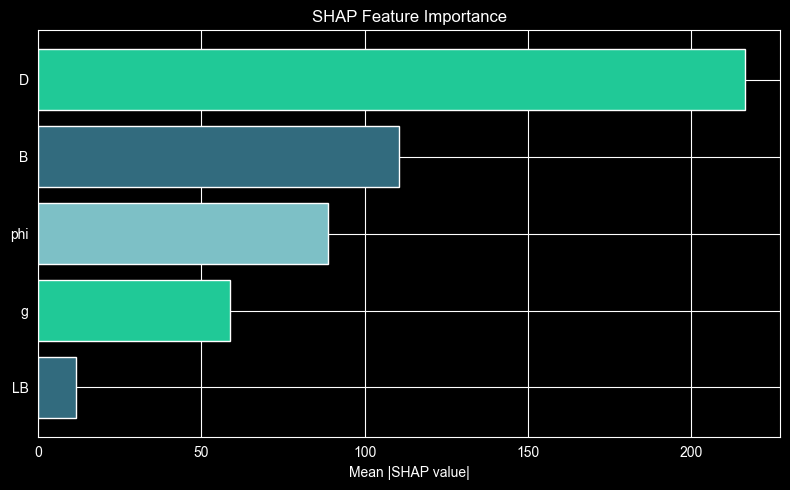

In [35]:
# based oon XGBoost
import shap, numpy as np
import matplotlib.pyplot as plt

sv = shap.TreeExplainer(XGB_model_best)(X_test_XGB)
imp = np.abs(sv.values).mean(axis=0)
idx = np.argsort(imp)

plt.figure(figsize=(8,5))
plt.barh(X_test_XGB.columns[idx], imp[idx],
         color=['#326B7E','#20C997','#7DC0C6'] * 2)
plt.xlabel('Mean |SHAP value|')
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.show()

ExactExplainer explainer: 29it [00:29,  1.08s/it]                        


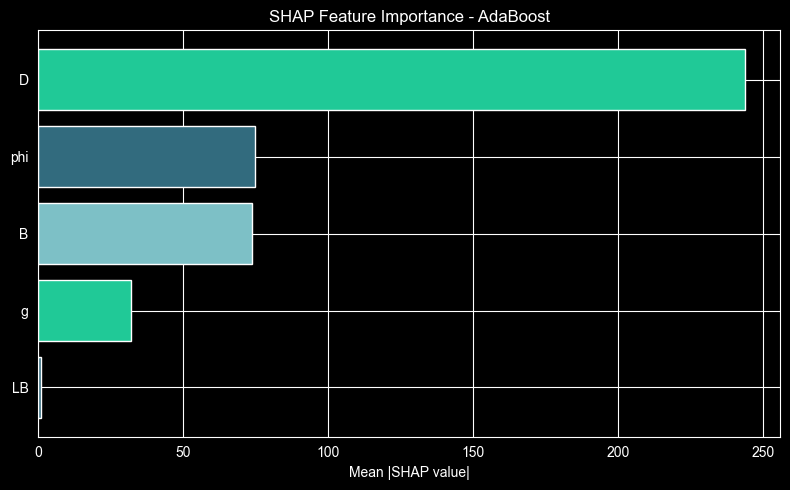

In [34]:
# based on AdaBoost
import shap, numpy as np
import matplotlib.pyplot as plt

explainer = shap.Explainer(AdaB_model_best.predict, X_train_AdaB)
sv = explainer(X_test_AdaB)

imp = np.abs(sv.values).mean(axis=0)
idx = np.argsort(imp)

plt.figure(figsize=(8,5))
plt.barh(X_test_AdaB.columns[idx], imp[idx],
         color=['#326B7E','#20C997','#7DC0C6'] * 2)
plt.xlabel('Mean |SHAP value|')
plt.title('SHAP Feature Importance - AdaBoost')
plt.tight_layout()
plt.show()

## Extracting Models for Desktop GUI

In [33]:
import joblib

# SR equation stored directly as text
SR_equation = (
    "(Ngamma + (g*D)**2 * (D/B - sin(phi)**2)) "
    "* (B*5.938716 + g*D)"
)

# Everything needed by the GUI
models_data = {
    "XGBoost": XGB_model_best,
    "AdaBoost": AdaB_model_best,

    # Symbolic Regression equation (NOT a model)
    "SR_equation": SR_equation,

    # Input features expected by XGBoost/AdaBoost
    "features": ["B", "D", "g", "phi", "LB"],

    # Target
    "target": "BC"
}

# Save everything into ONE file
joblib.dump(models_data, "UBC_models.pkl")

print("All models and SR equation saved successfully!")
print("File: UBC_models.pkl")

All models and SR equation saved successfully!
File: UBC_models.pkl


In [5]:
import joblib
import pandas as pd

models = joblib.load("UBC_models.pkl")

xgb = models["XGBoost"]
ada = models["AdaBoost"]

print("XGBoost features:")
print(xgb.feature_names_in_ if hasattr(xgb, "feature_names_in_") else "No feature names")

print("\nAdaBoost features:")
print(ada.feature_names_in_ if hasattr(ada, "feature_names_in_") else "No feature names")

# Test one input
X = pd.DataFrame(
    [[3, 1.0, 18, 32, 2]],
    columns=["B", "D", "g", "phi", "LB"]
)

print("\nInput:")
print(X)

print("\nXGBoost prediction:", xgb.predict(X)[0])
print("AdaBoost prediction:", ada.predict(X)[0])

C:\Users\Ayman\ai-env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ayman\ai-env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator AdaBoostRegressor from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


XGBoost features:
['B' 'D' 'g' 'phi' 'LB']

AdaBoost features:
['B' 'D' 'g' 'phi' 'LB']

Input:
   B    D   g  phi  LB
0  3  1.0  18   32   2

XGBoost prediction: 965.5304
AdaBoost prediction: 1019.4
